In [4]:
# Importing the course packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the course datasets c
climate_change = pd.read_csv('../datasets/climate_change.csv', parse_dates=["date"], index_col="date")
medals = pd.read_csv('../datasets/medals_by_country_2016.csv', index_col=0)
summer_2016 = pd.read_csv('../datasets/summer2016.csv')
austin_weather = pd.read_csv("../datasets/austin_weather.csv", index_col="DATE")
weather = pd.read_csv("../datasets/seattle_weather.csv", index_col="DATE")

# Some pre-processing on the weather datasets, including adding a month column
seattle_weather = weather[weather["STATION"] == "USW00094290"] 
month = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"] 
seattle_weather["MONTH"] = month 
austin_weather.loc[:,"MONTH"] = month

C:\Users\lucfi\AppData\Local\Temp\ipykernel_61520\950236909.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seattle_weather["MONTH"] = month


# Changing plot style

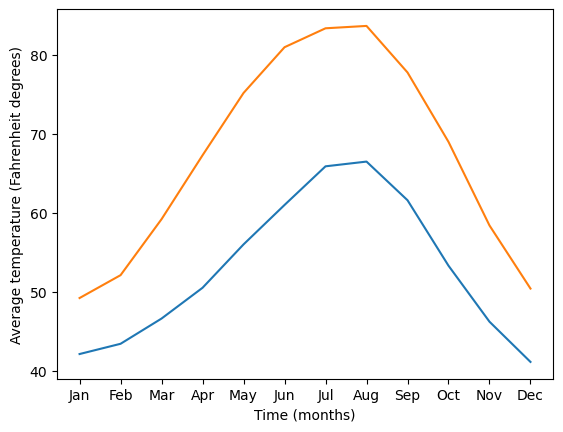

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"])
ax.plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"])
ax.set_xlabel("Time (months)")
ax.set_ylabel("Average temperature (Fahrenheit degrees)")
plt.show()

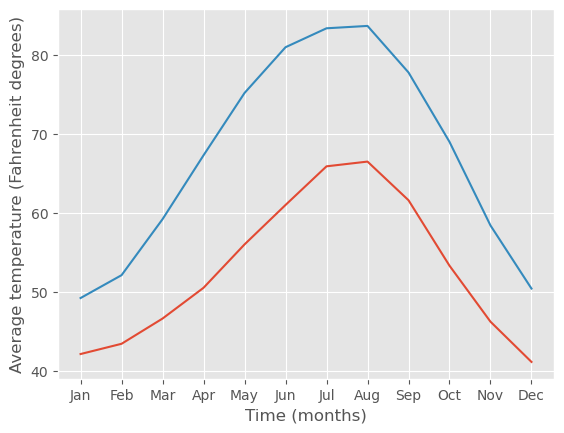

In [10]:
# Choosing a style
plt.style.use("ggplot")
fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"])
ax.plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"])
ax.set_xlabel("Time (months)")
ax.set_ylabel("Average temperature (Fahrenheit degrees)")
plt.show()

#ggplot style now applies to all figures in the session, until changed back

## Guidelines for choosing plotting style

- Avoid dark backgrounds
- Consider colorblind-friendly options if color is important
- Avoid colored backgrounds for printing
- Use grayscale if black-and-white printing is likely

# Saving visualizations

## Saving the figure to file
- Use the "savefig()" method on the ***FIGURE*** object

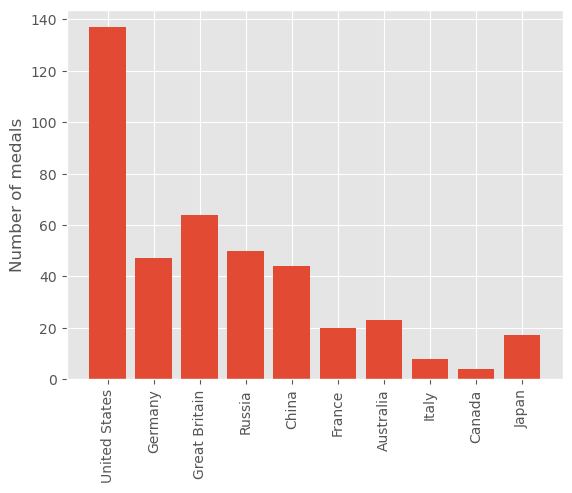

In [21]:
fig, ax = plt.subplots()

ax.bar(medals.index, medals["Gold"])
ax.tick_params(axis='x', rotation=90)
ax.set_ylabel("Number of medals")

fig.savefig("gold_medals.png") # can specify format using the filename, ex "gold_medals.jpg"
fig.savefig("gold_medals_low.jpg", pil_kwargs={"quality": 50}) #Need to use pil_kwargs and a dictionary to specify quality like this
fig.savefig("gold_medals_hi.jpg", dpi=300)

In [23]:
# Setting size:
fig.set_size_inches([5,3])
fig.savefig("gold_metals_5_3.jpg")

# Automating figures from data

In [25]:
sports = summer_2016["Sport"].unique()
print(sports)

['Rowing' 'Taekwondo' 'Handball' 'Wrestling' 'Gymnastics' 'Swimming'
 'Basketball' 'Boxing' 'Volleyball' 'Athletics' 'Rugby Sevens' 'Judo'
 'Rhythmic Gymnastics' 'Weightlifting' 'Equestrianism' 'Badminton'
 'Water Polo' 'Football' 'Fencing' 'Shooting' 'Sailing' 'Beach Volleyball'
 'Canoeing' 'Hockey' 'Cycling' 'Tennis' 'Diving' 'Table Tennis'
 'Triathlon' 'Archery' 'Synchronized Swimming' 'Modern Pentathlon'
 'Trampolining' 'Golf']


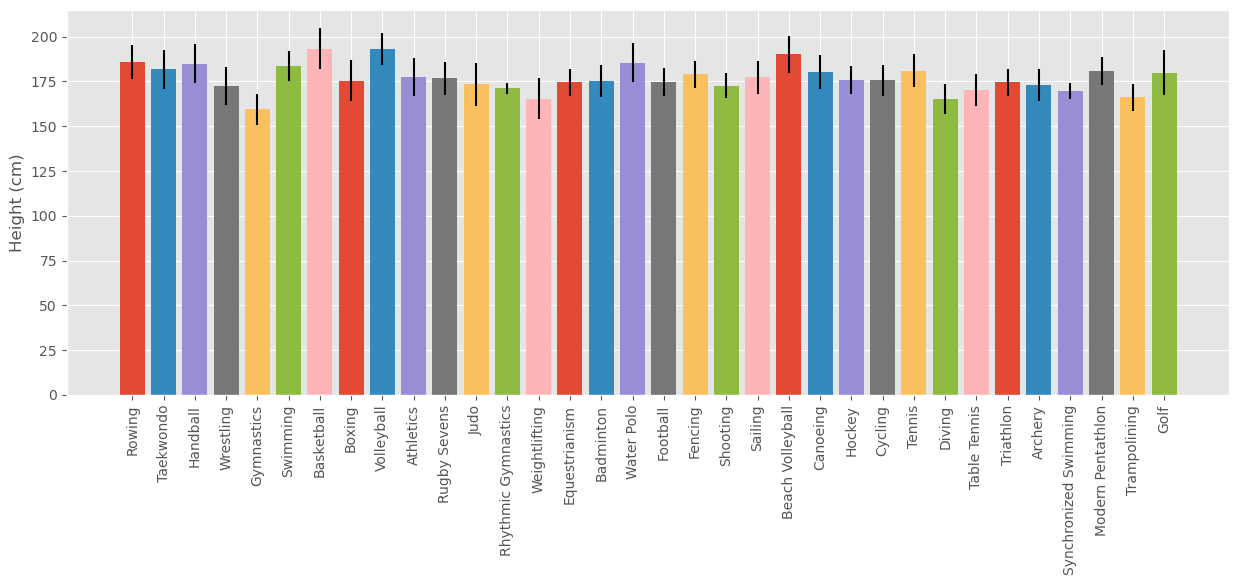

In [31]:
fig, ax = plt.subplots()

# Iterate over the unique sports (found in cell above)
for sport in sports:
    sport_df = summer_2016[summer_2016["Sport"]==sport]
    ax.bar(sport, sport_df["Height"].mean(),yerr=sport_df["Height"].std())
ax.set_ylabel("Height (cm)")
ax.tick_params(axis='x', rotation=90)
fig.set_size_inches([15,5]) #Adjust dimensions to taste
plt.show()